<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>RNN Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
Everything till now took a fixed size input, an image of 8x8 or a row of features. A sequence is diffrent, the length changes and the order carries meaning. An RNN handles that by keeping a hidden state and updating it one step at a time, so what it saw earlier is still with it.
</div>

## why a normal network is not enough

two problems with feeding a sequence to a dense layer:

1. the input size is fixed, a 10 word sentence and a 30 word sentence cannot both go in
2. if we just add up or average the inputs then the order is gone, and order is the whole point in a sequence

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = [1, 2, 3, 4]
b = [4, 3, 2, 1]

print("sum   :", sum(a), sum(b))
print("mean  :", np.mean(a), np.mean(b))
print("but the two sequences are clearly not the same thing")

sum   : 10 10
mean  : 2.5 2.5
but the two sequences are clearly not the same thing


## the fix, carry a hidden state

at every time step the network takes the current input and the previous hidden state, and produces a new hidden state:

```
h_t = tanh(x_t * Wx  +  h_(t-1) * Wh  +  b)
```

`h` is the memory. it starts at zero and gets updated at every step. the same Wx and Wh are used at every step, that is called weight sharing and it is why any length works.

## doing it by hand

setting the weights myself (no training here) so its clear what the loop does. taking Wx = 1 and Wh = 1 with no tanh, then the hidden state becomes a running total.

In [2]:
def step(x, h, Wx=1.0, Wh=1.0):
    return x * Wx + h * Wh

seq = [1, 2, 3, 4]
h = 0
for t, x in enumerate(seq):
    h = step(x, h)
    print("t =", t, " input =", x, " hidden =", h)

t = 0  input = 1  hidden = 1.0
t = 1  input = 2  hidden = 3.0
t = 2  input = 3  hidden = 6.0
t = 3  input = 4  hidden = 10.0


In [10]:
# same numbers in the reverse order, and now with Wh = 0.5 so old stuff fades
def run(seq, Wh):
    h = 0
    for x in seq:
        h = step(x, h, Wh=Wh)
    return h

print("forward order 1,2,3,4 :", run([1,2,3,4], 0.5))
print("reverse order 4,3,2,1 :", run([4,3,2,1], 0.5))

forward order 1,2,3,4 : 6.125
reverse order 4,3,2,1 : 3.25


with Wh = 0.5 the older inputs get halved every step, so the last input matters most and the two orders give diffrent answers. thats memory with a forgetting factor, wich is basicaly what a real RNN learns.

## with tanh, the way it is actually done

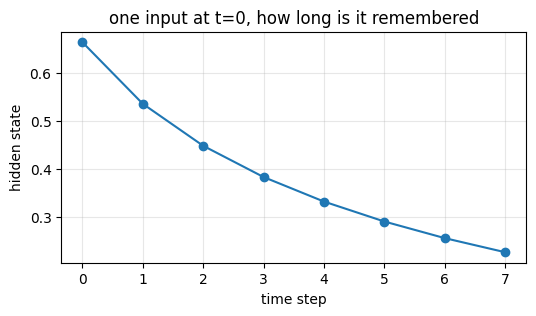

[np.float64(0.664), np.float64(0.535), np.float64(0.448), np.float64(0.382), np.float64(0.331), np.float64(0.29), np.float64(0.255), np.float64(0.225)]


In [5]:
def rnn_step(x, h, Wx, Wh, b):
    return np.tanh(x * Wx + h * Wh + b)

Wx, Wh, b = 0.8, 0.9, 0.0
seq = [1, 0, 0, 0, 0, 0, 0, 0]

h = 0.0
states = []
for x in seq:
    h = rnn_step(x, h, Wx, Wh, b)
    states.append(h)

plt.figure(figsize=(6,3))
plt.plot(states, 'o-')
plt.xlabel('time step'); plt.ylabel('hidden state')
plt.title('one input at t=0, how long is it remembered')
plt.grid(alpha=.3)
plt.show()
print([round(s,3) for s in states])

only the first step has an input, after that the signal just decays. this is the memory of the network and how fast it fades depends on Wh.

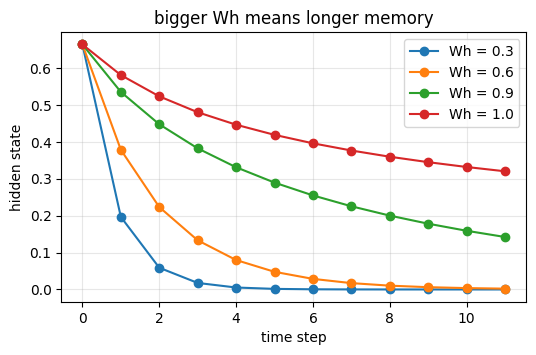

In [7]:
plt.figure(figsize=(6,3.5))
for wh in [0.3, 0.6, 0.9, 1.0]:
    h, hist = 0.0, []
    for x in [1] + [0]*11:
        h = rnn_step(x, h, 0.8, wh, 0.0)
        hist.append(h)
    plt.plot(hist, 'o-', label='Wh = ' + str(wh))
plt.legend(); plt.grid(alpha=.3)
plt.xlabel('time step'); plt.ylabel('hidden state')
plt.title('bigger Wh means longer memory')
plt.show()

small Wh forgets almost immediately. Wh near 1 holds on much longer. if Wh goes above 1 it blows up instead, and if its small the signal dies before it reaches the loss, thats the vanishing gradient problem wich the LSTM in the next folder solves.

## unrolling

the loop drawn out looks like a deep network where every layer is the same weights:

```
x0        x1        x2        x3
 |         |         |         |
h0  ->    h1   ->   h2   ->   h3   ->  output
```

so backprop through an RNN is just normal backprop on this unrolled chain, it has a name, BPTT (backpropagation through time).

## a hidden state with more than one number

in a real RNN `h` is a vector, so it can remember diffrent things in diffrent slots at the same time.

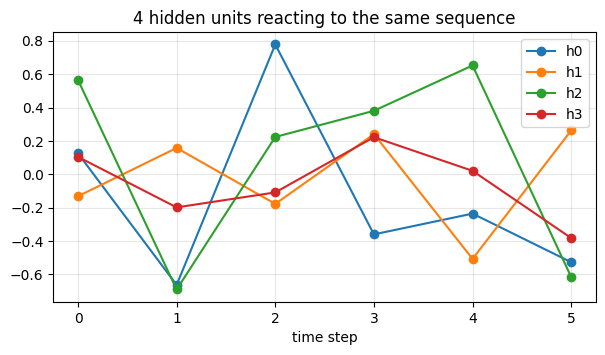

In [8]:
rng = np.random.default_rng(0)
H = 4
Wx = rng.normal(0, 1, (1, H))
Wh = rng.normal(0, 0.5, (H, H))
b  = np.zeros(H)

seq = [1, -1, 0.5, 0, 2, -0.5]
h = np.zeros(H)
track = []

for x in seq:
    h = np.tanh(np.array([[x]]) @ Wx + h @ Wh + b).ravel()
    track.append(h.copy())

track = np.array(track)
plt.figure(figsize=(7,3.5))
for i in range(H):
    plt.plot(track[:,i], 'o-', label='h' + str(i))
plt.xlabel('time step'); plt.legend(); plt.grid(alpha=.3)
plt.title('4 hidden units reacting to the same sequence')
plt.show()

each unit reacts differently to the same input because each one has its own weights. after training, some units end up tracking one thing and some another.

### recap
- an RNN is a loop, `h_t = tanh(x_t Wx + h_(t-1) Wh + b)`
- same weights at every step, so any sequence length works
- the hidden state is the memory and Wh decides how fast it fades
- unrolled it is just a deep net, so backprop still works, its called BPTT

next notebook i write this loop and its BPTT in numpy and train it on a real signal.